<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png" width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# Heston — Calibración de Mercado I (Sesión 5)
---
Hasta ahora resolvimos el problema **directo**: dados los parámetros, calcular precios. La calibración es el problema **inverso**: dados precios de mercado observados, encontrar los parámetros que los reproducen.

$$\text{Parámetros } (v_0,\theta,\kappa,\xi,\rho) \;\xrightarrow{\text{pricing (directo)}}\; \text{Precios}$$
$$\text{Precios de mercado} \;\xrightarrow{\text{calibración (inverso)}}\; \text{Parámetros}$$

En esta primera sesión montamos la maquinaria: **función de pérdida, restricciones, y la optimización en dos etapas**. Descargamos datos reales desde Yahoo Finance y hacemos una primera calibración.


## 0. Librerias

In [1]:
import numpy as np
from scipy.stats import qmc
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# yfinance para datos reales (instalar con: pip install yfinance)
try:
    import yfinance as yf
    YF_OK = True
except ImportError:
    YF_OK = False
    print("yfinance no instalado. Ejecuta:  pip install yfinance")

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11,'lines.linewidth':2})
PURPLE='#534AB7'; GREEN='#1D9E75'; ORANGE='#D85A30'; AMBER='#BA7517'; BLUE='#2A7FBF'


## 1. Motor de pricing (reutilizado)

Las mismas funciones de siempre. Añadimos la vol implicita por bisección, que necesitaremos para comparar en unidades de volatilidad.


In [2]:
def heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho):
    i=1j; uj=0.5 if j==1 else -0.5; bj=kappa-rho*xi if j==1 else kappa
    dj=np.sqrt((rho*xi*i*u-bj)**2+xi**2*(u**2-2*uj*i*u))
    g2j=(bj-rho*xi*i*u+dj)/(bj-rho*xi*i*u-dj)
    Dj=((bj-rho*xi*i*u+dj)/xi**2)*((1-np.exp(dj*tau))/(1-g2j*np.exp(dj*tau)))
    Cj=r*i*u*tau+(kappa*theta/xi**2)*((bj-rho*xi*i*u+dj)*tau-2*np.log((1-g2j*np.exp(dj*tau))/(1-g2j)))
    return np.exp(Cj+Dj*v+i*u*x)

def heston_prob_j(j,x,v,tau,K,r,kappa,theta,xi,rho):
    lnK=np.log(K)
    ig=lambda u:np.real(np.exp(-1j*u*lnK)*heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho)/(1j*u))
    val,_=quad(ig,1e-8,200,limit=200); return 0.5+val/np.pi

def heston_call(S,K,r,tau,v0,kappa,theta,xi,rho):
    x=np.log(S)
    return (S*heston_prob_j(1,x,v0,tau,K,r,kappa,theta,xi,rho)
            - K*np.exp(-r*tau)*heston_prob_j(2,x,v0,tau,K,r,kappa,theta,xi,rho))

def bs_call(S,K,r,tau,sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); d2=d1-sigma*np.sqrt(tau)
    return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)

def bs_implied_vol(price,S,K,r,tau,tol=1e-7):
    intr=max(S-K*np.exp(-r*tau),0.0)
    if price<=intr+1e-8: return np.nan
    lo,hi=1e-6,5.0
    for _ in range(100):
        mid=(lo+hi)/2; d=bs_call(S,K,r,tau,mid)-price
        if abs(d)<tol: return mid
        lo,hi=(mid,hi) if d<0 else (lo,mid)
    return mid


## 2. Descargar datos reales de opciones (Yahoo Finance)

Elegimos un ticker liquido (por defecto **SPY**, el ETF del S&P 500) y descargamos su cadena de opciones. Yahoo entrega, para cada vencimiento, todos los strikes con su bid/ask, volumen e interés abierto.

> **Nota sobre la ejecución:** si `yfinance` no puede conectarse (sin internet, o Yahoo bloquea), la siguiente celda genera una **superficie sintética** con parámetros conocidos, para que el notebook siempre corra. En clase, con internet, usarás datos reales.


In [3]:
TICKER = "SPY"       # cambia por AAPL, MSFT, ^SPX, etc.
r      = 0.045       # tasa libre de riesgo aproximada (ajustar al momento)

def descargar_cadena_yahoo(ticker):
    """Descarga calls de las primeras n_expiries fechas de vencimiento."""
    tk = yf.Ticker(ticker)                          # crea el objeto de Yahoo Finance para el ticker (ej. "SPY")
    S0 = tk.history(period="1d")["Close"].iloc[-1]  # descarga 1 día de precios y toma el último cierre como spot S0
    hoy = np.datetime64('today')                    # fecha de hoy, para calcular tiempo a vencimiento
    filas = []                                      # lista donde se acumulan los quotes limpios
    for exp in tk.options:             # itera sobre las primeras n_expiries fechas de vencimiento disponibles
        chain = tk.option_chain(exp).calls          # descarga la cadena de opciones de esa fecha y se queda solo con los calls
        T = (np.datetime64(exp) - hoy) / np.timedelta64(365,'D')  # convierte la fecha de vencimiento a tiempo en años (T)
        if T <= 0: continue                         # descarta vencimientos ya pasados o de hoy (T no positivo)
        for _, row in chain.iterrows():              # recorre cada strike (fila) de la cadena de ese vencimiento
            bid, ask = row['bid'], row['ask']        # extrae bid y ask de esa opción
            if bid > 0 and ask > 0 and row['volume'] > 0:  # filtra quotes ilíquidos: exige bid, ask y volumen positivos
                mid = 0.5*(bid+ask)                  # calcula el precio mid como promedio de bid y ask
                filas.append((row['strike'], T, mid, ask-bid, row['volume']))  # guarda (strike, T, precio mid, spread, volumen)
    return float(S0), np.array(filas)                # regresa el spot S0 y la matriz de todos los quotes recolectados


S0, raw = descargar_cadena_yahoo(TICKER)
FUENTE = f"Yahoo Finance ({TICKER})"
print(f"Descargados {len(raw)} quotes reales. Spot S0 = {S0:.2f}")

Descargados 4641 quotes reales. Spot S0 = 747.71


## 3. Limpieza de datos

Los quotes crudos vienen sucios. Antes de calibrar (siguiendo la presentación 20/21):
- **Precios mid:** $(bid+ask)/2$, guardando el spread como señal de calidad.
- **Filtrar iliquidos:** quitar strikes con volumen cero o spreads absurdos.
- **Quitar ITM profundo:** aportan poca información de volatilidad.

Nos quedamos con opciones cercanas al dinero (moneyness entre 0.85 y 1.15).


En resumen: esta parte filtra la cadena cruda para quedarse solo con opciones líquidas y cercanas al dinero (moneyness 0.85–1.15), arma la lista market que alimentará la calibración, y grafica la sonrisa de volatilidad implícita observada por cada vencimiento — todo sobre la cadena completa del índice, no un contrato aislado.

¿Por qué quitamos opciones ITM profundas?
Dos razones, una financiera y una numérica.

**Vega y contenido informativo.** El vega de una opción (sensibilidad del precio a la volatilidad) tiene forma de campana: máximo cerca del dinero (K≈S0) y cae hacia cero conforme te alejas en cualquier dirección. Una opción ITM profunda vale casi puro valor intrínseco ($S-Ke^{-rT}$), así que su precio depende casi linealmente del spot y casi nada de $\sigma$ — no importa qué volatilidad uses en Heston, el precio modelo cambia poco. Lo mismo pasa con OTM profundo: el precio es casi cero, dominado por la cola de la distribución, y también con vega mínimo. En ambos extremos la opción aporta poca señal sobre qué volatilidad reproduce el mercado, así que meterla en la función de pérdida es casi ruido puro.

**Inestabilidad numérica al invertir.** `bs_implied_vol` invierte Black-Scholes: dado un precio, busca $\sigma$. Si el precio está muy cerca del valor intrínseco (típico en ITM profundo), la función `bs_implied_vol` es casi plana en $\sigma$ para ese precio — pequeños errores de bid-ask (redondeo, spread) se traducen en enormes saltos de vol implícita, o directamente la función regresa `nan` (la condición `price <= intr+1e-8` del código). En OTM profundo pasa algo análogo: el precio es tan chico que el spread bid-ask es una fracción enorme del precio, y la vol implícita se vuelve muy ruidosa.

Por eso el filtro de moneyness 0.85–1.15 se queda con la región cerca del dinero: ahí el vega es alto, los spreads son más apretados (más liquidez) y la inversión a vol implícita es estable — justo la zona donde el precio realmente "habla" de la volatilidad.

Quotes tras limpieza: 91 (de 4641)
Fuente: Yahoo Finance (SPY)


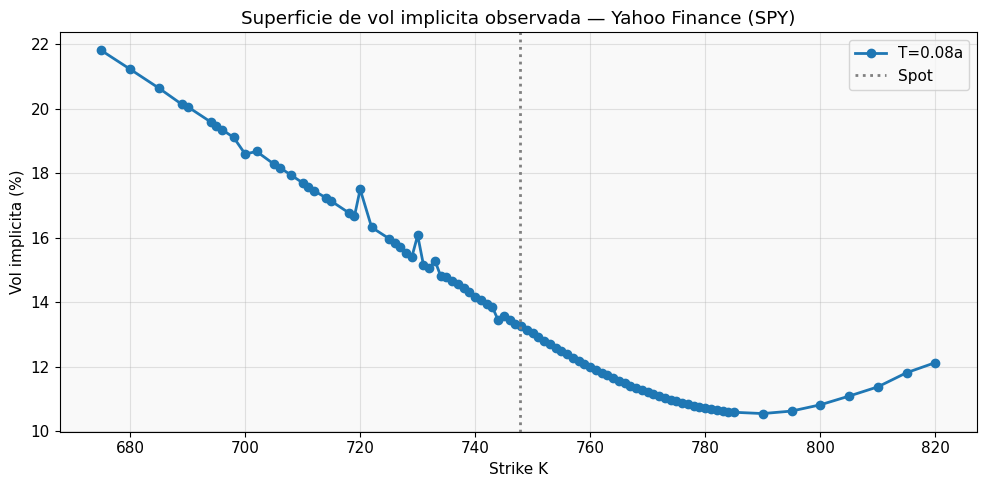

In [4]:
K_col, T_col, mid_col, spread_col, vol_col = 0,1,2,3,4
# asigna nombres legibles a los índices de columna del array raw (strike, T, mid, spread, volumen)

moneyness = raw[:,K_col] / S0
# calcula el moneyness de cada opción: strike dividido entre el spot S0

mask = (moneyness > 0.90) & (moneyness < 1.10) & (raw[:,mid_col] > 0.05) & (raw[:,T_col] > 30/365) & (raw[:,T_col] < 32/365)
# construye un filtro booleano: se queda con moneyness entre 0.85 y 1.15 (cerca del dinero)
# y con precio mid mayor a 0.05 (descarta opciones casi sin valor / basura numérica)

data = raw[mask]
# aplica el filtro y deja solo las filas que cumplen ambas condiciones

market = [(row[K_col], row[T_col], row[mid_col], row[spread_col]) for row in data]
# reconstruye la lista de tuplas (strike, T, precio mid, spread) que usará la calibración
# nota: descarta la columna de volumen, ya no se necesita después de filtrar

print(f"Quotes tras limpieza: {len(market)} (de {len(raw)})")
# imprime cuántos quotes sobrevivieron la limpieza vs. el total original

print(f"Fuente: {FUENTE}")
# imprime si los datos vinieron de Yahoo Finance real o de la superficie sintética (fallback)

# Vista rapida de la superficie de vol implicita observada
fig, ax = plt.subplots(figsize=(10,5))
# crea una figura y un eje para graficar

for T in sorted(set(row[1] for row in market)):
    # itera sobre cada vencimiento único T presente en market, en orden ascendente

    Ks  = [row[0] for row in market if row[1]==T]
    # extrae todos los strikes que pertenecen a ese vencimiento T

    ivs = [bs_implied_vol(row[2],S0,row[0],r,row[1])*100 for row in market if row[1]==T]
    # para cada quote de ese vencimiento, invierte Black-Scholes (precio mid -> vol implícita)
    # y la convierte a porcentaje

    orden=np.argsort(Ks)
    # obtiene los índices que ordenarían los strikes de menor a mayor (para que la línea no se cruce al graficar)

    ax.plot(np.array(Ks)[orden], np.array(ivs)[orden], 'o-', label=f'T={T:.2f}a')
    # grafica vol implícita vs strike para ese vencimiento, ordenado, con marcador y línea

ax.axvline(S0, color='gray', ls=':', label='Spot')
# dibuja una línea vertical punteada en el spot S0, como referencia visual de "at-the-money"

ax.set_xlabel('Strike K'); ax.set_ylabel('Vol implicita (%)')
# etiqueta los ejes

ax.set_title(f'Superficie de vol implicita observada — {FUENTE}'); ax.legend()
# pone título (indicando la fuente de datos) y muestra la leyenda con cada vencimiento

plt.tight_layout(); plt.show()
# ajusta márgenes para que no se corten las etiquetas y muestra la gráfica


## 4. La función de pérdida

Calibrar es minimizar una **función de pérdida** que mide la distancia entre modelo y mercado:

$$\mathcal{L}(\Theta) = \sum_{i=1}^{N} w_i\,\bigl[\,g_{\text{modelo}}(K_i,T_i;\Theta) - g_{\text{mkt}}(K_i,T_i)\,\bigr]^2$$

Usamos error en **precio** ponderado por el inverso del spread al cuadrado: así las opciones con bid-ask apretado (más liquidas, más confiables) pesan más en el ajuste.


`w` en la función de pérdida es el **peso** que se le da al error de cada opción individual dentro de la suma. La pérdida es una suma ponderada de errores al cuadrado — $\mathcal{L}=\sum_i w_i(C_i^{mdl}-C_i^{mkt})^2$ — así que $w_i$ controla cuánto "le importa" al optimizador acertarle a esa opción en particular. Si $w_i$ es grande, un error de precio ahí penaliza mucho la pérdida total y el optimizador se esfuerza por ajustarla bien; si $w_i$ es chico, esa opción prácticamente no influye y el ajuste puede ignorarla sin costo. Sin pesos (todos $w_i=1$), cada quote pesaría lo mismo sin importar qué tan confiable sea.

La razón de relacionarlo con el spread es estadística: el precio mid ($=(bid+ask)/2$) que usamos como "el" precio de mercado no es un dato perfecto — es solo el punto medio entre lo que alguien pagaría y lo que alguien cobraría. El spread es literalmente el tamaño de esa banda de incertidumbre alrededor del mid. Un spread angosto significa que compradores y vendedores casi coinciden en el precio, así que el mid es una estimación confiable del "valor justo". Un spread ancho significa que hay mucha incertidumbre o falta de consenso — el verdadero precio podría estar en cualquier punto de ese rango amplio, así que el mid es un estimador ruidoso.

Esto conecta directo con mínimos cuadrados ponderados: si tratas el spread como un proxy de la desviación estándar del ruido de esa observación ($\sigma_i\approx\text{spread}_i$), la ponderación óptima bajo un modelo Gaussiano de ruido es exactamente $w_i=1/\sigma_i^2$ — así penalizas más los residuos de las observaciones confiables (spread chico → $\sigma_i$ chico → $w_i$ grande) y casi ignoras las ruidosas (spread grande → $w_i$ chico). El cuadrado en `spread**2` no es arbitrario: viene de que la varianza es el cuadrado de la desviación estándar, y la pérdida ya está en unidades cuadráticas de precio.

Económicamente tiene el mismo sentido que vimos con moneyness y liquidez: spreads angostos suelen darse en opciones líquidas, con mucha competencia de market makers, donde el precio observado sí refleja bien la volatilidad de mercado. Spreads anchos suelen darse en opciones ilíquidas (strikes raros, poco volumen), donde el quote incluye un margen de riesgo del market maker más que información pura de precio. Sin este peso, la calibración gastaría esfuerzo tratando de encajar perfectamente esos quotes ruidosos, distorsionando el ajuste en las zonas donde sí hay señal confiable.

El `max(spread, 0.01)` es solo un piso de seguridad: evita dividir entre cero (o un spread absurdamente chico) que haría que $w_i\to\infty$ y esa sola opción dominara toda la función de pérdida, ignorando a todas las demás.

In [5]:
def loss(params, market, S0, r):
    v0, theta, kappa, xi, rho = params
    total = 0.0
    for K, T, price_mkt, spread in market:
        try:
            price_mdl = heston_call(S0, K, r, T, v0, kappa, theta, xi, rho)
            w = 1.0 / max(spread, 0.01)**2          # peso por liquidez
            total += w * (price_mdl - price_mkt)**2
        except Exception:
            total += 1e6                             # penaliza params invalidos
    return total

# Prueba con un punto arbitrario
test = (0.04, 0.04, 1.5, 0.5, -0.5)
print("Loss en punto de prueba:", round(loss(test, market, S0, r), 4))


Loss en punto de prueba: 1201984.0779


## 5. Restricciones de parámetros

El optimizador debe respetar el dominio del modelo:

| Parámetro | Restricción | Razón |
|-----------|-------------|-------|
| $v_0$ | $>0$ | varianza positiva |
| $\theta$ | $>0$ | varianza de largo plazo positiva |
| $\kappa$ | $>0$ | reversión (no explosión) |
| $\xi$ | $>0$ | vol-de-vol positiva |
| $\rho$ | $\in(-1,1)$ | correlación valida |

La condición de Feller la dejamos **libre** (no la imponemos): el mercado puede exigir un skew que la viole.


In [6]:
bounds = [
    (0.005, 0.20),   # v0
    (0.005, 0.20),   # theta
    (0.10,  6.00),   # kappa
    (0.05,  1.50),   # xi
    (-0.95, 0.50),   # rho
]
nombres = ['v0','theta','kappa','xi','rho']


## 6. Optimización en dos etapas

La superficie de pérdida es **no convexa**: tiene múltiples mínimos locales y valles planos. Por eso usamos la estrategia estándar en dos etapas:

1. **Búsqueda global** (`differential_evolution`) para ubicar la cuenca correcta.
2. **Refinamiento local** (`least_squares`, Levenberg-Marquardt) para precisión y velocidad.


In [10]:
# print("Etapa 1: busqueda global (dual annealing)...")
# solo un mensaje indicando que empieza la etapa 1

# global_fit = differential_evolution(
#     loss, bounds, args=(market, S0, r),
#     seed=1, maxiter=1, tol=1e-7, polish=True, disp=False, workers=-1, updating='deferred')
# corre búsqueda global tipo evolución diferencial sobre la función loss
# bounds: los rangos válidos de cada parámetro (v0, theta, kappa, xi, rho)
# args: parámetros extra que loss necesita además de los 5 a calibrar (market, S0, r)
# seed=1: fija la semilla aleatoria, para que el resultado sea reproducible
# maxiter=20: máximo de generaciones del algoritmo evolutivo
# tol=1e-7: criterio de convergencia (para de iterar si la mejora es menor a esto)
# polish=True: al terminar, aplica un pulido local (L-BFGS-B) sobre el mejor punto encontrado
# disp=False: no imprime el progreso iteración por iteración
# from scipy.optimize import dual_annealing
# global_fit = dual_annealing(loss, bounds, args=(market, S0, r), maxiter=20, seed=1)

print("Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...")
# ya no usamos differential_evolution: en su lugar, escaneamos el espacio de
# parametros con pocos puntos bien distribuidos y solo refinamos localmente los
# mas prometedores -- mismo espiritu de "explorar antes de refinar", pero con un
# numero de evaluaciones caras que tu controlas directamente (mucho mas rapido)

def residuals(params):
    # funcion de residuos que necesita least_squares (regresa un vector, uno por
    # quote, a diferencia de loss que regresa un solo escalar)

    v0,theta,kappa,xi,rho = params
    # desempaqueta el vector de parametros en sus 5 nombres

    res=[]
    # lista donde se acumula un residuo por cada opcion del mercado

    for K,T,price_mkt,spread in market:
        # itera sobre cada quote (strike, vencimiento, precio mid, spread)

        w = 1.0/max(spread,0.01)
        # peso por liquidez: inverso del spread (piso de 0.01 para no dividir entre ~0)
        # aqui es 1/spread, no 1/spread^2 como en loss -- least_squares ya eleva el
        # residuo al cuadrado internamente, asi que el cuadrado se aplica una sola vez

        try:
            pm = heston_call(S0,K,r,T,v0,kappa,theta,xi,rho)
            # precio del modelo Heston para esos parametros y ese (K,T)

            res.append(w*(pm - price_mkt))
            # guarda el residuo ponderado: error de precio * peso de liquidez

        except Exception:
            res.append(1e3)
            # si falla la evaluacion (parametros que rompen la integral, etc.),
            # castiga con un residuo grande en vez de tronar el optimizador

    return res
    # regresa el vector completo de residuos (uno por quote)


def busqueda_global_rapida(bounds, market, S0, r, n_candidatos=40, n_refinar=4, seed=1):
    # reemplazo de differential_evolution: escanea el espacio de parametros con
    # pocos puntos, y solo refina localmente los mas prometedores

    lb = np.array([b[0] for b in bounds]); ub = np.array([b[1] for b in bounds])
    # limites inferior y superior de cada parametro, como arrays de numpy

    muestra = qmc.LatinHypercube(d=len(bounds), seed=seed).random(n_candidatos)
    # genera n_candidatos puntos en el cubo unitario [0,1]^5, repartidos de forma
    # uniforme en las 5 dimensiones (mejor cobertura que puntos aleatorios puros
    # para el mismo numero de muestras)

    candidatos = lb + muestra*(ub-lb)
    # escala el cubo [0,1]^5 a los bounds reales de cada parametro (v0,theta,kappa,xi,rho)

    perdidas = [loss(c, market, S0, r) for c in candidatos]
    # evalua la funcion de perdida en cada candidato -- estas son las unicas N
    # evaluaciones "caras" del escaneo global, sin generaciones ni poblaciones repetidas

    mejores_idx = np.argsort(perdidas)[:n_refinar]
    # indices de los n_refinar candidatos con menor perdida (los mas prometedores)

    mejor_fit = None
    # aqui se va guardando el mejor resultado de refinamiento local encontrado

    i = 1
    print(f"Refinando localmente los {n_refinar} mejores candidatos del escaneo global...")
    for idx in mejores_idx:
        # refina localmente cada uno de los candidatos prometedores, no solo el
        # mejor del escaneo -- cubre el riesgo de que el "mejor" del escaneo no
        # sea el que mejor termina convergiendo (valles pianos, minimos cercanos)

        fit = least_squares(residuals, candidatos[idx], bounds=(lb,ub), max_nfev=10)
        print(f"Fit {i} de {n_refinar}: costo={fit.cost:.4f}, params={fit.x}")
        i += 1
        # refinamiento local (TRF, por los bounds) arrancando desde ese candidato

        if mejor_fit is None or fit.cost < mejor_fit.cost:
            mejor_fit = fit
            # se queda con el refinamiento que termino en menor costo de los n_refinar

    return mejor_fit
    # regresa el objeto de least_squares con el mejor ajuste encontrado


mejor_fit = busqueda_global_rapida(bounds, market, S0, r, n_candidatos=10, n_refinar=4, seed=1)
# corre todo el proceso: escaneo global barato + refinamiento local sobre los
# candidatos mas prometedores

theta_fit = mejor_fit.x
# guarda los parametros finales calibrados

print("  Loss final:", round(2*mejor_fit.cost, 5))
# mejor_fit.cost es 0.5*suma(residuos^2) (convencion interna de least_squares);
# se multiplica por 2 para reportarlo en las mismas unidades que 'loss'

print("  Params calibrados:", {n: round(v,4) for n,v in zip(nombres, theta_fit)})
# imprime los parametros finales, emparejados con sus nombres

Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...
Refinando localmente los 4 mejores candidatos del escaneo global...
Fit 1 de 4: costo=21.2726, params=[ 0.01172981  0.09811525  2.38734143  0.8108646  -0.67109659]
Fit 2 de 4: costo=22.7947, params=[ 0.01441209  0.06366913  2.77927428  0.76583736 -0.66577939]
Fit 3 de 4: costo=28.1460, params=[ 0.01803951  0.06191185  0.79738047  0.64401199 -0.65979576]
Fit 4 de 4: costo=27.5815, params=[ 0.01769417  0.05668158  1.21055116  0.67199686 -0.66044982]
  Loss final: 42.54512
  Params calibrados: {'v0': np.float64(0.0117), 'theta': np.float64(0.0981), 'kappa': np.float64(2.3873), 'xi': np.float64(0.8109), 'rho': np.float64(-0.6711)}


## 7. Evaluación del ajuste

Comparamos la sonrisa del modelo calibrado contra la observada, por vencimiento. Deben superponerse. Reportamos también el RMSE en puntos de volatilidad.

Para qué sirve calibrar contra todo el mercado: los 5 parámetros de Heston no son observables directamente — nadie te dice "hoy κ=2.3\kappa=2.3
κ=2.3". Lo único que observas son precios de opciones líquidas. Calibrar es el proceso de traducir esos precios observados en un conjunto de parámetros que, usados en el modelo, reproducen (aproximadamente) toda la superficie de volatilidad simultáneamente. Una vez que tienes esos parámetros, tienes una dinámica de precios completa y consistente con el mercado de hoy — y el punto de eso no es re-derivar precios que ya conocías (esos ya los tenías, son los quotes con los que calibraste), sino poder valuar con esa misma dinámica cualquier cosa para la que no tengas un precio de mercado directo: un strike específico poco líquido, una fecha de vencimiento no estándar, una opción exótica (barreras, asiáticas, varianza), o simplemente para calcular griegas de cobertura consistentes con toda la sonrisa en vez de una sola opción aislada. Esa es la idea: un solo conjunto de parámetros describe todo el mercado, así que no recalibras por cada contrato — usas los mismos (v0,θ,κ,ξ,ρ)(v_0,\theta,\kappa,\xi,\rho)
(v0​,θ,κ,ξ,ρ) para cualquier (K,T)(K,T)
(K,T) que necesites, metiéndolos a heston_call (o su análogo para puts vía paridad put-call).

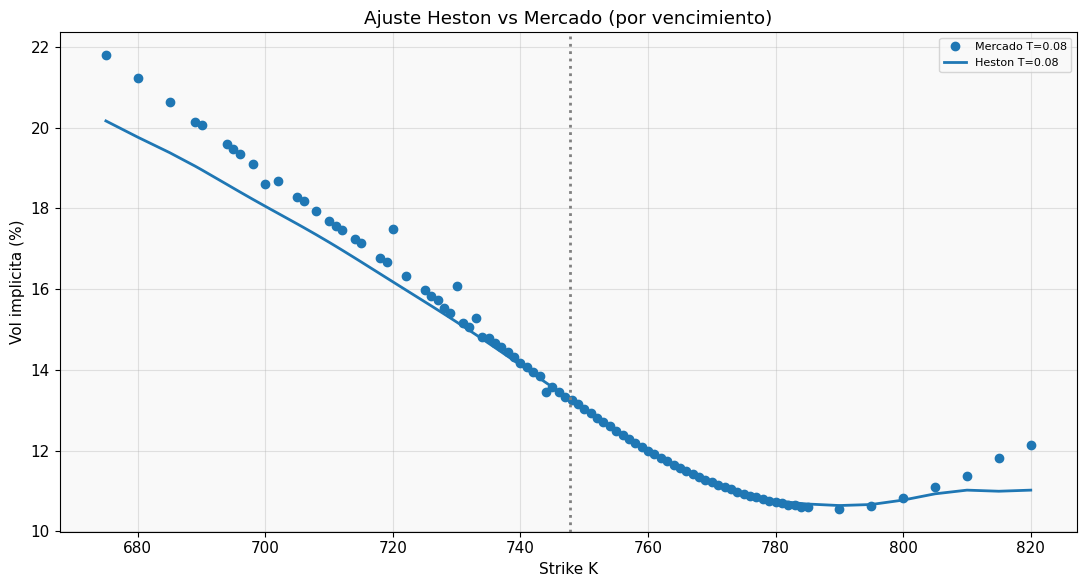

RMSE del ajuste: 0.484 puntos de volatilidad
Condicion de Feller: VIOLADA (2*kappa*theta=0.468, xi^2=0.658)


In [11]:
fig, ax = plt.subplots(figsize=(11,6))
# crea la figura y el eje donde se graficara el ajuste

errores = []
# lista donde se acumularan los errores (modelo - mercado) en puntos de vol implicita, de todos los vencimientos

for T in sorted(set(row[1] for row in market)):
    # itera sobre cada vencimiento unico T presente en market, en orden ascendente

    filas_T = [row for row in market if row[1]==T]
    # filtra solo los quotes que pertenecen a ese vencimiento T

    Ks = np.array([row[0] for row in filas_T]); orden=np.argsort(Ks); Ks=Ks[orden]
    # extrae los strikes de ese vencimiento, calcula el orden ascendente y reordena Ks
    # (necesario para que la linea del plot no se cruce de un lado a otro)

    iv_mkt = np.array([bs_implied_vol(row[2],S0,row[0],r,T)*100 for row in filas_T])[orden]
    # invierte Black-Scholes sobre el precio mid observado de cada quote para obtener
    # la vol implicita de mercado, en porcentaje, y la reordena con el mismo orden que Ks

    iv_mdl = []
    for K in Ks:
        # para cada strike (ya ordenado), calcula el precio segun Heston calibrado

        pm = heston_call(S0,K,r,T,theta_fit[0],theta_fit[2],theta_fit[1],theta_fit[3],theta_fit[4])
        # precio del modelo Heston usando los parametros calibrados (theta_fit)
        # nota el reordenamiento de argumentos: heston_call espera (v0,kappa,theta,xi,rho)
        # pero theta_fit esta en orden (v0,theta,kappa,xi,rho) -- por eso se pasan
        # theta_fit[0],theta_fit[2],theta_fit[1],... intercambiando kappa y theta

        iv_mdl.append(bs_implied_vol(pm,S0,K,r,T)*100)
        # invierte ese precio modelo a vol implicita (%), para comparar en las mismas unidades

    iv_mdl=np.array(iv_mdl)
    # convierte la lista de vols del modelo a array de numpy

    errores.extend(iv_mdl - iv_mkt)
    # acumula el error puntual (modelo - mercado) de este vencimiento en la lista global de errores

    l=ax.plot(Ks, iv_mkt, 'o', label=f'Mercado T={T:.2f}')[0]
    # grafica la vol implicita observada como puntos ('o'), guarda el objeto de linea
    # para reutilizar su color en la curva del modelo

    ax.plot(Ks, iv_mdl, '-', color=l.get_color(), label=f'Heston T={T:.2f}')
    # grafica la vol implicita del modelo como linea continua, mismo color que los puntos
    # de mercado de ese vencimiento (para poder comparar visualmente el par)

ax.axvline(S0, color='gray', ls=':')
# dibuja una linea vertical punteada en el spot, como referencia de "at-the-money"

ax.set_xlabel('Strike K'); ax.set_ylabel('Vol implicita (%)')
# etiqueta los ejes

ax.set_title('Ajuste Heston vs Mercado (por vencimiento)'); ax.legend(fontsize=8)
# titulo del grafico y leyenda (chica, porque hay una entrada por cada vencimiento x2)

plt.tight_layout(); plt.show()
# ajusta margenes y muestra la figura

rmse = np.sqrt(np.mean(np.array(errores)**2))
# calcula el RMSE global: junta los errores de TODOS los vencimientos y strikes en un
# solo vector, y saca la raiz del error cuadratico medio -- una sola cifra resumen del ajuste

print(f"RMSE del ajuste: {rmse:.3f} puntos de volatilidad")
# imprime el RMSE en puntos de vol implicita (ej. 1.234 significa ~1.2 puntos porcentuales de error tipico)

feller = 2*theta_fit[2]*theta_fit[1] >= theta_fit[3]**2
# evalua si los parametros calibrados cumplen la condicion de Feller: 2*kappa*theta >= xi^2
# (nota otra vez el orden: theta_fit[2]=kappa, theta_fit[1]=theta, theta_fit[3]=xi)

print(f"Condicion de Feller: {'CUMPLE' if feller else 'VIOLADA'} "
      f"(2*kappa*theta={2*theta_fit[2]*theta_fit[1]:.3f}, xi^2={theta_fit[3]**2:.3f})")
# imprime si se cumple o viola la condicion, junto con los dos valores numericos comparados


## 8. Resumen y puente hacia Calibración II

Montamos el pipeline completo: datos → limpieza → pérdida → optimización en dos etapas → evaluación. 

Lo que **falta** y veremos en la siguiente sesión (Calibración II):
- Chequeos de **no-arbitraje** antes de calibrar (monotonia, convexidad, calendario).
- El problema de **identificabilidad** $\kappa$–$\xi$: parámetros que saltan aunque el ajuste sea bueno.
- **Validación** rigurosa y los **límites estructurales** de Heston (skew de corto plazo, ausencia de saltos).

> **Punto pedagógico:** si usaste la superficie sintética, compara los parámetros calibrados con los verdaderos que se imprimieron en la sección 2. Es probable que $v_0$ y $\rho$ se recuperen bien, pero $\kappa$, $\xi$ y $\theta$ no exactamente — aunque el ajuste sea excelente. Ese es el problema de identificabilidad, y es el tema central de la próxima sesión.
